# Cookbook 3: fixed individuals across SLiM loci

This recipe simulates one population with a shared pedigree across 30 loci,
samples four diploid individuals once, and fits their pooled DGS. Independent
population replicates assess variation among fixed samples. Recombination
between loci does not remove their shared individual selfing histories.


In [1]:
from pathlib import Path
import tempfile
import subprocess

import numpy as np
import pandas as pd

from selfdgs.plotting import plot_likelihood_curve
from selfdgs.validation import ValidationExperimentConfig, run_validation_experiment

In [2]:
print(subprocess.run(["slim", "-v"], capture_output=True, text=True).stdout)

SLiM version 5.2, built Apr 12 2026 02:46:55
Git commit SHA-1: unknown (built from a non-Git source archive)



## Configure the experiment

Simulate 30 loci with a burn-in of 10 times the diploid census size. Adjacent loci
are separated by a nonmutating spacer with recombination probability 0.5.
`n_loci` sets the number of loci in the population.

SLiM 5.2 must be installed and available on `PATH`. Results go to a temporary directory.


In [3]:
output_dir = Path(tempfile.mkdtemp()) / 'slim_validation'
config = ValidationExperimentConfig(
    sampling_design="fixed_individuals",
    outdir=output_dir,
    census_size=100,
    true_s=0.5,
    n_reps=1,
    n_loci=30,
    chrom_length_each=20_000,
    mu=1e-5,
    burn_mult=10,
    s_grid=np.linspace(0, 0.95, 96),
)
pd.Series({
    'true selfing rate': config.true_s,
    'loci': f'{config.n_loci}',
    'length per locus': f'{config.chrom_length_each:,} bp',
    'sampled diploids': f'{config.n_sample}',
    'mutation rate': f'{config.mu:g}',
    'burn-in': f'{config.burn_mult * config.census_size:,} generations',
})

true selfing rate                  0.5
loci                                30
length per locus             20,000 bp
sampled diploids                     4
mutation rate                    1e-05
burn-in              1,000 generations
dtype: object

## Simulate and fit

Each replicate uses one population seed and samples the same individuals across
all loci. `sample.vcf` holds the multilocus genotypes. `sampled_individuals.csv`
maps VCF columns to population indices and records consecutive selfing generations
(`-1` denotes an unknown history because no outcross was observed).


[W::vcf_parse] Contig 'A' is not defined in the header. (Quick workaround: index the file with tabix.)


generating s               0.5
estimated s                0.0
support interval     0.00–0.00
segregating sites         4025
loci                        30
dtype: object

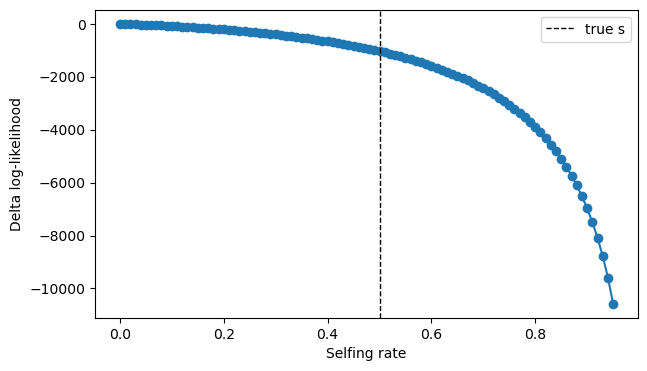

In [4]:
result = run_validation_experiment(config)[0]
summary = pd.Series({
    'generating s': result.true_s,
    'estimated s': result.fit.best_s,
    'support interval': f'{result.fit.support_interval[0]:.2f}–{result.fit.support_interval[1]:.2f}',
    'segregating sites': result.fit.n_sites,
    'loci': sum(locus.n_loci for locus in result.vcf_results),
})
display(summary)
plot_likelihood_curve(result.fit, true_s=config.true_s);

The dashed line marks the generating selfing rate, 0.5. With the specified
seed and four fixed individuals, the displayed fit peaks at 0.0 and reports
support of 0.00–0.00. That means only the boundary grid point meets the chosen
log-likelihood cutoff; it does not mean the population rate is known exactly
or that a calibrated confidence interval has zero width.

The model averages over individual selfing histories rather than conditioning
on the histories realized in this sample. Thousands of sites can therefore
produce a sharply concentrated profile away from the generating rate. This
single realization illustrates the distinction; it does not measure estimator
bias or coverage. Those require independent population replicates. Refining
the grid can resolve the profile more finely, but does not calibrate uncertainty.
Both shared histories and linkage within loci can produce dependence.


## Evaluate recovery across populations

Set `n_reps` above 1 to simulate independent populations and fixed samples at
each configuration. Vary census size, true selfing rate, sample size, and locus
count, using a separate output directory per configuration. The CLI equivalent
is `selfdgs simulate --sampling-design fixed_individuals`.

Each experiment writes `validation_config.json` and `validation_summary.csv`.
Each `repNNN` directory contains the sample VCF and manifest, DGS and likelihood
tables, fitted result, simulation metadata in `vcfs.csv`, and SLiM logs. Under
this design, `vcfs.csv` has one row for the multilocus VCF with its `n_loci` count.

For experiments stored under `validation/`, consolidate results with:

```python
from selfdgs.validation import (
    discover_validation_runs,
    load_validation_collection,
    summarize_estimator_recovery,
)

runs = discover_validation_runs("validation")
estimates = load_validation_collection(runs)
recovery = summarize_estimator_recovery(estimates)
```

Recovery is summarized separately by census size, true selfing rate, sample
size, locus count, and sampling design when those columns are available.
One replicate demonstrates execution, not sampling precision or interval coverage.
Repeated or nested samples from one population are not independent replicates.

For a control that averages over histories at each locus, set
`sampling_design="independent_populations"`. This simulates
a separate population and sample per locus. Keep that design separate when
assessing recovery for fixed-individual genomic data.
